In [1]:
#importing liabraries
import pandas as pd
import numpy as np

df = pd.read_csv('spam.csv', encoding='latin-1')
print("Raw shape:", df.shape)
df.head()


Raw shape: (5572, 5)


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [2]:
df = df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'])
df = df.rename(columns={'v1': 'target', 'v2': 'text'})
df.head()


,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
# Check for missing values,duplicates and remove duplicates
print("Missing values:\n", df.isnull().sum())
 
print("\nDuplicate rows:", df.duplicated().sum())

df = df.drop_duplicates(keep='first')
print("Shape after removing duplicates:", df.shape)


Missing values:
 target    0
text      0
dtype: int64

Duplicate rows: 403
Shape after removing duplicates: (5169, 2)


In [4]:
# Encode target: ham -> 0, spam -> 1
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])   # ham=0, spam=1
df.head()


,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


target
0    4516
1     653
Name: count, dtype: int64


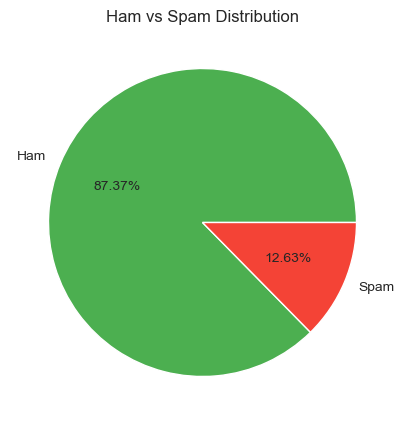

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

print(df['target'].value_counts())

plt.figure(figsize=(5,5))
plt.pie(df['target'].value_counts(), labels=['Ham', 'Spam'], autopct='%0.2f%%',
        colors=['#4CAF50', '#F44336'])
plt.title('Ham vs Spam Distribution')
plt.show()


In [6]:
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Feature engineering for EDA: character, word, sentence counts

df['num_characters'] = df['text'].apply(len)
df['num_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))
df['num_sentences'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

df[['num_characters', 'num_words', 'num_sentences']].describe()


,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [7]:
# Compare stats for ham vs spam

print("HAM stats:")
print(df[df['target'] == 0][['num_characters','num_words','num_sentences']].describe())
print("\nSPAM stats:")
print(df[df['target'] == 1][['num_characters','num_words','num_sentences']].describe())


HAM stats:
       num_characters    num_words  num_sentences
count     4516.000000  4516.000000    4516.000000
mean        70.459256    17.123782       1.820195
std         56.358207    13.493970       1.383657
min          2.000000     1.000000       1.000000
25%         34.000000     8.000000       1.000000
50%         52.000000    13.000000       1.000000
75%         90.000000    22.000000       2.000000
max        910.000000   220.000000      38.000000

SPAM stats:
       num_characters   num_words  num_sentences
count      653.000000  653.000000     653.000000
mean       137.891271   27.667688       2.970904
std         30.137753    7.008418       1.488425
min         13.000000    2.000000       1.000000
25%        132.000000   25.000000       2.000000
50%        149.000000   29.000000       3.000000
75%        157.000000   32.000000       4.000000
max        224.000000   46.000000       9.000000


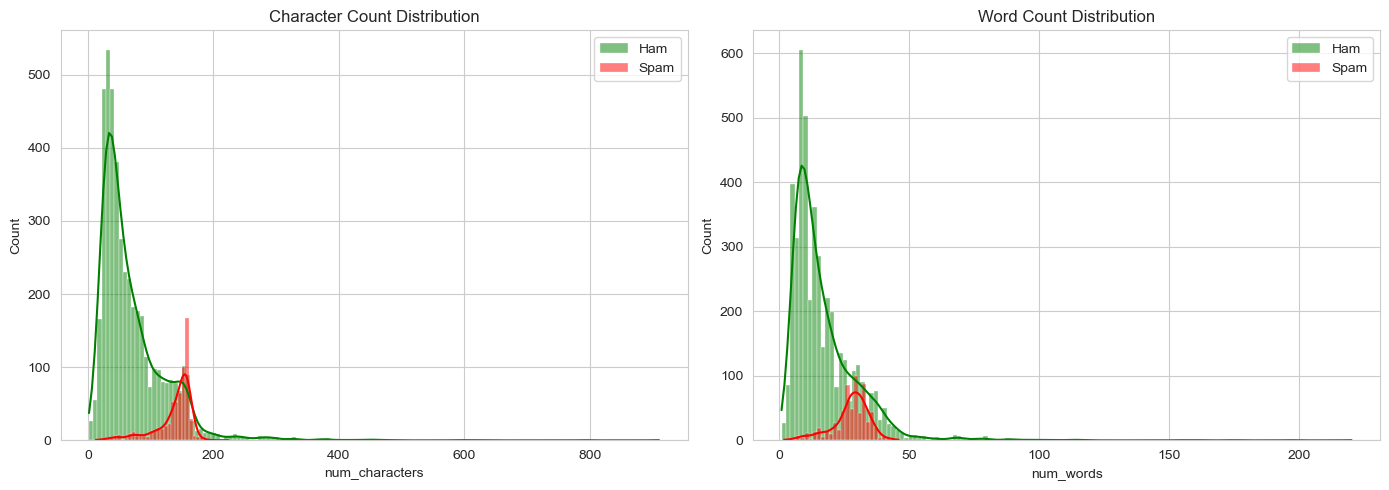

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(df[df['target']==0]['num_characters'], color='green', label='Ham', kde=True, ax=axes[0])
sns.histplot(df[df['target']==1]['num_characters'], color='red', label='Spam', kde=True, ax=axes[0])
axes[0].set_title('Character Count Distribution')
axes[0].legend()

sns.histplot(df[df['target']==0]['num_words'], color='green', label='Ham', kde=True, ax=axes[1])
sns.histplot(df[df['target']==1]['num_words'], color='red', label='Spam', kde=True, ax=axes[1])
axes[1].set_title('Word Count Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()



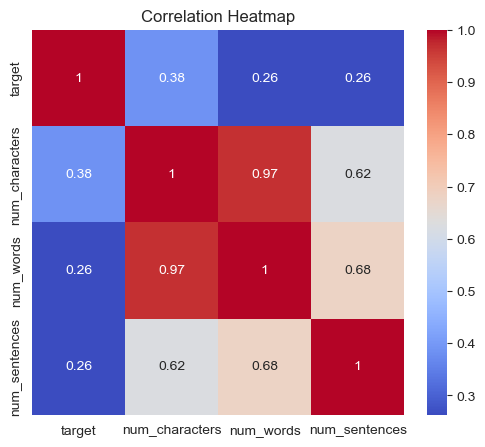

In [9]:
# Correlation heatmap of the numeric features with target

plt.figure(figsize=(6,5))
sns.heatmap(df[['target','num_characters','num_words','num_sentences']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [10]:
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import string

ps = PorterStemmer()

def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    # keep only alphanumeric tokens
    
    text = [word for word in text if word.isalnum()]

    # remove stopwords and punctuation
    
    text = [word for word in text if word not in stopwords.words('english') and word not in string.punctuation]

    # stemming
    
    text = [ps.stem(word) for word in text]

    return " ".join(text)

# quick test

transform_text("Hi, I am winning a FREE lottery!! Click http://scam.com NOW to claim $$$")


'hi win free lotteri click http claim'

In [11]:
df['transformed_text'] = df['text'].apply(transform_text)
df[['text', 'transformed_text']].head(10)


,text,transformed_text
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri 2 wkli comp win fa cup final tkt 21...
3,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darl 3 week word back like fun sti...
6,Even my brother is not like to speak with me. ...,even brother like speak treat like aid patent
7,As per your request 'Melle Melle (Oru Minnamin...,per request mell oru minnaminungint nurungu ve...
8,WINNER!! As a valued network customer you have...,winner valu network custom select receivea pri...
9,Had your mobile 11 months or more? U R entitle...,mobil 11 month u r entitl updat latest colour ...


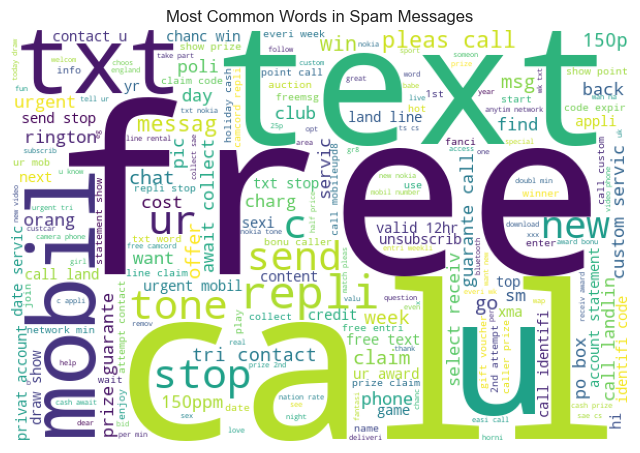

In [12]:
# Visualize most common words in spam using a WordCloud

from wordcloud import WordCloud

wc = WordCloud(width=600, height=400, background_color='white')
spam_wc = wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=' '))

plt.figure(figsize=(8,6))
plt.imshow(spam_wc)
plt.axis('off')
plt.title('Most Common Words in Spam Messages')
plt.show()


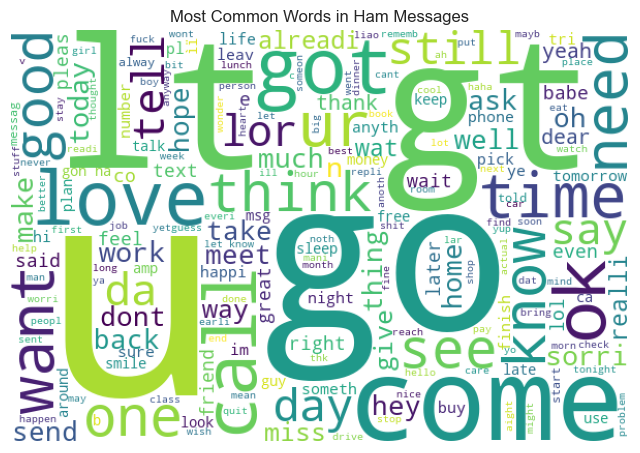

In [13]:
ham_wc = wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=' '))

plt.figure(figsize=(8,6))
plt.imshow(ham_wc)
plt.axis('off')
plt.title('Most Common Words in Ham Messages')
plt.show()

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['transformed_text']).toarray()
y = df['target'].values

print("Feature matrix shape:", X.shape)



Feature matrix shape: (5169, 3000)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2, stratify=y)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])


Train size: 4135
Test size: 1034


In [16]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix

classifiers = {
    'Gaussian NB': GaussianNB(),
    'Multinomial NB': MultinomialNB(),
    'Bernoulli NB': BernoulliNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'SVM': SVC(kernel='sigmoid', gamma=1.0),
    'Random Forest': RandomForestClassifier(n_estimators=50, random_state=2),
    'Extra Trees': ExtraTreesClassifier(n_estimators=50, random_state=2)
}
print("Models ready:", list(classifiers.keys()))


Models ready: ['Gaussian NB', 'Multinomial NB', 'Bernoulli NB', 'Logistic Regression', 'SVM', 'Random Forest', 'Extra Trees']


In [28]:
results = []

for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    train_pred=clf.predict(X_train)
    train_acc=accuracy_score(y_train,train_pred)
    
    test_pred=clf.predict(X_test)
    test_acc=accuracy_score(y_test,test_pred)

    results.append({
        'model': name,
        'training Accuracy': train_acc,
        'test Accuracy': test_acc
    })
results_df=pd.DataFrame(results)
results_df
    

,model,training Accuracy,test Accuracy
0,Gaussian NB,0.896977,0.876209
1,Multinomial NB,0.979444,0.983559
2,Bernoulli NB,0.985732,0.988395
3,Logistic Regression,0.964933,0.962282
4,SVM,0.981620,0.987427
5,Random Forest,0.999274,0.982592
6,Extra Trees,0.999516,0.986460


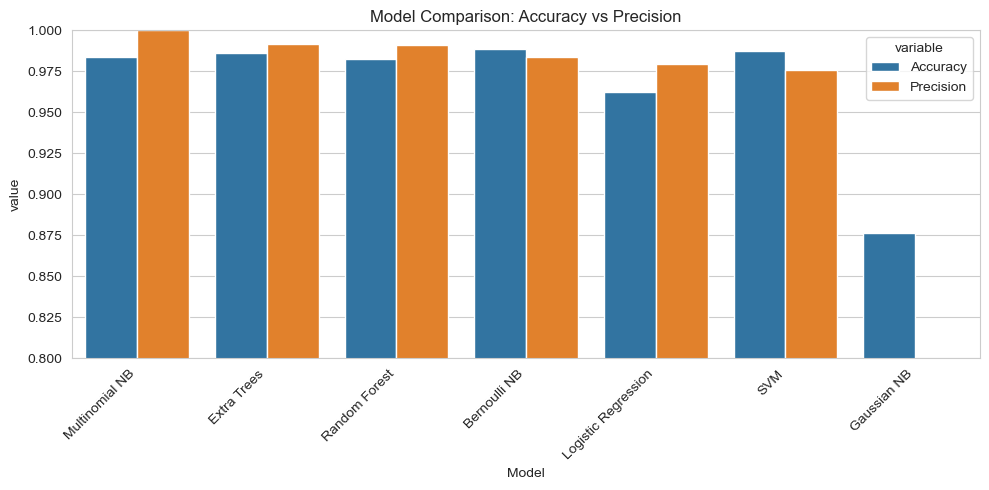

In [18]:
plt.figure(figsize=(10,5))
results_melted = results_df.melt(id_vars='Model', value_vars=['Accuracy','Precision'])
sns.barplot(data=results_melted, x='Model', y='value', hue='variable')
plt.xticks(rotation=45, ha='right')
plt.ylim(0.8, 1.0)
plt.title('Model Comparison: Accuracy vs Precision')
plt.tight_layout()
plt.show()



Best model: Multinomial NB


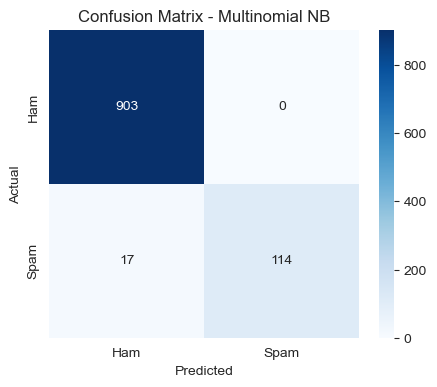

In [19]:
best_model_name = results_df.iloc[0]['Model']
best_model = classifiers[best_model_name]
print("Best model:", best_model_name)

y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham','Spam'], yticklabels=['Ham','Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

In [20]:
# Try Multinomial Naive Bayes with different TF-IDF settings

tfidf_v2 = TfidfVectorizer(max_features=3000)
X_v2 = tfidf_v2.fit_transform(df['transformed_text']).toarray()
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_v2, y, test_size=0.2, random_state=2, stratify=y)
mnb = MultinomialNB()
mnb.fit(X_train2, y_train2)
y_pred2 = mnb.predict(X_test2)
print("Accuracy:", accuracy_score(y_test2, y_pred2))
print("Precision:", precision_score(y_test2, y_pred2))


Accuracy: 0.9835589941972921
Precision: 1.0


In [22]:
# Try combining with an additional numeric feature: num_characters, scaled

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
extra_feature = scaler.fit_transform(df[['num_characters']])
X_combined = np.hstack((X_v2, extra_feature))
X_train3, X_test3, y_train3, y_test3 = train_test_split(X_combined, y, test_size=0.2, random_state=2, stratify=y)
rf = RandomForestClassifier(n_estimators=100, random_state=2)
rf.fit(X_train3, y_train3)
y_pred3 = rf.predict(X_test3)
print("Accuracy with extra feature:", accuracy_score(y_test3, y_pred3))
print("Precision with extra feature:", precision_score(y_test3, y_pred3))


Accuracy with extra feature: 0.9816247582205029
Precision with extra feature: 0.9827586206896551


In [23]:
# Finalize the model we will deploy

final_tfidf = tfidf_v2
final_model = mnb
print("Final model: Multinomial Naive Bayes")
print("Final Accuracy:", accuracy_score(y_test2, y_pred2))
print("Final Precision:", precision_score(y_test2, y_pred2))


Final model: Multinomial Naive Bayes
Final Accuracy: 0.9835589941972921
Final Precision: 1.0


In [24]:
def predict_message(message):
    transformed = transform_text(message)
    vector = final_tfidf.transform([transformed]).toarray()
    result = final_model.predict(vector)[0]
    return "SPAM" if result == 1 else "HAM"

test_messages = [
    "Congratulations! You've WON a free iPhone. Click here to claim now!!!",
    "Hey, are we still meeting for lunch tomorrow?",
    "URGENT: Your account has been suspended. Verify immediately at this link.",
]

for msg in test_messages:
    print(f"{msg}\n--> {predict_message(msg)}\n")


Congratulations! You've WON a free iPhone. Click here to claim now!!!
--> SPAM

Hey, are we still meeting for lunch tomorrow?
--> HAM

URGENT: Your account has been suspended. Verify immediately at this link.
--> SPAM

